# Replicating a Model in "Deep Residual Learning for Image Recognition"

Paper Title: Deep Residual Learning for Image Recognition [1]

Authors: Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun

Link: https://arxiv.org/abs/1512.03385

Here I replicate the 34-layer residual network. The architecture and the hyperparameters are stated in the paper, sections 3.3 and 3.4 and table 1.

The paper refers to [3], [4], [5] and [6] for the details. I follow the paper in following those details.

Following the original paper, I use the ImageNet dataset [2] for training and testing the model.

I download the dataset from the following Kaggle competition page: https://www.kaggle.com/c/imagenet-object-localization-challenge

Import the necessary packages.

In [1]:
import math

import matplotlib.pyplot as plt

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from custom_transforms import fancy_pca, random_resize, subtract_per_pixel_mean
from custom_datasets import ImageNetValDataset

/usr/lib/python3/dist-packages/pyparsing/core.py:5640: SyntaxWarning: 'return' in a 'finally' block
  return self.__class__.__name__ + ": " + retString


## Pre-Processing the Training Data

The pre-processing of the training data is detailed in 3.4 of [1].

1. The image is resized with its shorter side randomly sampled in [256, 480] for scale augmentation, following [3].
2. Per-pixel mean is subtracted from the image, following 2 of [4].
3. A 224×224 crop is randomly sampled from an image or its horizontal flip, following 4.1 of [4].
4. The standard color augmentation in 4.1 of [4] is used. Detailed method is outlined here: https://aparico.github.io/
5. The images are grouped into batches of size 256.

In [2]:
batch_size = 256
num_workers = 6

In [3]:
train_transform = transforms.Compose([
    transforms.ToTensor(), # converts the range of pixel values from 0-255 to 0-1
    transforms.Lambda(random_resize),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(fancy_pca),
    transforms.Lambda(subtract_per_pixel_mean)
])

In [4]:
train_set = datasets.ImageFolder(
    root="./imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train",
    transform=train_transform
)

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=2
)

In [5]:
val_transform = transforms.Compose([
    transforms.ToTensor(), # converts the range of pixel values from 0-255 to 0-1
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(subtract_per_pixel_mean)
])

In [6]:
val_set = ImageNetValDataset(
    val_img_dir="./imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val",
    val_annot_dir="./imagenet-object-localization-challenge/ILSVRC/Annotations/CLS-LOC/val",
    class_to_idx=train_set.class_to_idx, 
    transform=val_transform
)

val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=2
)

## Model Architecture

The model architecture is detailed in 3.4, 4.1, Figure 1 right, and Table 1 of [1].

* I adopt batch normalization (BN) right after each convolution and before activation, following [5]. Implemented in PyTorch here: https://docs.pytorch.org/docs/2.12/generated/torch.nn.BatchNorm2d.html
* I use ReLU activation after each convolution, following Figure 2 of [1].
* A shortcut connection is added to each pair of 3×3 filters. In this replication, I use identity mapping for all shortcuts and zero-padding for increasing dimensions.

Layers:

1. conv1: 7×7, 64, stride 2 - output 112×112
2. conv2_x: 3×3 max pool, stride 2 --> ((3×3, 64)×2, residual connection) × 3 - output 56×56
3. conv3_x: ((3×3, 128)×2, residual connection) × 4 - output 28×28
4. conv4_x: ((3×3, 256)×2, residual connection) × 6 - output 14×14
5. conv5_x: ((3×3, 512)×2, residual connection) × 3 - output 7×7
6. final: global average pooling --> 1000-d fully-connected layer --> softmax - output 1×1

* conv3_1, conv4_1, and conv5_1 have stride of 2, effectively down-sampling every time the number of channel increases.
* Appropriate paddings are added to preserve the output dimensions as specified above.

In [7]:
class ZeroPadShortcut(nn.Module):
    def __init__(self, pad_channels):
        super(ZeroPadShortcut, self).__init__()

        self.pad_channels = pad_channels

    def forward(self, x):
        x = F.pad(
            x[:, :, ::2, ::2],
            (0, 0, 0, 0, 0, self.pad_channels)
        )

        return x

In [8]:
class BasicBlock(nn.Module):
    def __init__(self, channels, stride_two=False):
        super(BasicBlock, self).__init__()

        if stride_two:
            self.shortcut = ZeroPadShortcut(channels // 2)
            self.conv1 = nn.Conv2d(in_channels=channels//2, out_channels=channels, kernel_size=3, padding=1, stride=2, bias=False)
        else:
            self.shortcut = nn.Sequential()
            self.conv1 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1, stride=1, bias=False)

        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(in_channels=channels, out_channels=channels, kernel_size=3, padding=1, stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)

        return out

In [9]:
class ResNet34(nn.Module):
   def __init__(self):
       super(ResNet34, self).__init__()

       self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, padding=3, stride=2, bias=False)
       self.bn1 = nn.BatchNorm2d(64)
       self.conv2 = nn.Sequential(*(
           [nn.MaxPool2d(kernel_size=3, padding=1, stride=2)]
           + [BasicBlock(64) for _ in range(3)]
       ))
       self.conv3 = nn.Sequential(*(
           [BasicBlock(128, True)]
           + [BasicBlock(128) for _ in range(3)]
       ))
       self.conv4 = nn.Sequential(*(
           [BasicBlock(256, True)]
           + [BasicBlock(256) for _ in range(5)]
       ))
       self.conv5 = nn.Sequential(*(
           [BasicBlock(512, True)]
           + [BasicBlock(512) for _ in range(2)]
       ))
       self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
       self.fc = nn.Linear(512, 1000)
       # self.softmax = nn.Softmax(dim=1)

   def forward(self, x):
       x = self.conv1(x)
       x = self.bn1(x)
       x = F.relu(x, inplace=True)
       x = self.conv2(x)
       x = self.conv3(x)
       x = self.conv4(x)
       x = self.conv5(x)
       x = self.avg_pool(x)
       x = x.view(-1, 512)
       x = self.fc(x)
       # x = self.softmax(x)

       return x

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResNet34().to(device)

## Training

Training process is detailed in 3.4 of [1].

* Weights are initialized as in [6].
* Weights are trained via mini-batch gradient descent, with mini-batch size 256.
* The learning rate starts from 0.1 and is divided by 10 when the error plateaus.
* Max iteration: 60 × 10^4
    * In this replication, I reduce the max iteration down to 60 × 10^3, due to time constraint.
* Weight decay: 0.0001
* Momentum: 0.9
* No dropout

Due to time constraint, in this replication, I make the following modifications.

* Max iteration: 60 × 10^3
* I wrap the forward pass with Automatic Mixed Precision.

In [11]:
def resnet34_init(m):
    if isinstance(m, nn.Conv2d):
        n = 1
        for i in range(1, 4):
            n *= m.weight.shape[i]
        nn.init.normal_(m.weight, std=math.sqrt(2 / n))
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.001)
        nn.init.zeros_(m.bias)

In [12]:
model.apply(resnet34_init)

ResNet34(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Sequential(
    (0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (1): BasicBlock(
      (shortcut): Sequential()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (2): BasicBlock(
      (shortcut): Sequential()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=0.0001, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

In [14]:
train_losses = []
val_losses = []

max_iter = 60000
num_epochs = max_iter // len(train_loader)

for epoch in range(num_epochs):
    model.train()
    print(f"Epoch [{epoch + 1}/{num_epochs}]", end=" ")

    scaler = torch.amp.GradScaler("cuda")

    train_loss = 0.0

    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        data = data.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            scores = model(data)
            loss = criterion(scores, targets)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}] Training Loss: {train_loss}")

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_index, (data, targets) in enumerate(tqdm(val_loader)):
            data = data.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
    
            scores = model(data)
            loss = criterion(scores, targets)
    
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}] Validation Loss: {val_loss}")

    scheduler.step(val_loss)

torch.save(model.state_dict(), "custom_resnet34.pth")

Epoch [1/11] 

100%|██████████| 5005/5005 [57:05<00:00,  1.46it/s]  


Epoch [1/11] Training Loss: 5.013228931531802


100%|██████████| 196/196 [02:06<00:00,  1.55it/s]


Epoch [1/11] Validation Loss: 3.947422675940455
Epoch [2/11] 

...

Epoch [10/11] Validation Loss: 2.405963513924151
Epoch [11/11] 

100%|██████████| 5005/5005 [57:51<00:00,  1.44it/s]  


Epoch [11/11] Training Loss: 2.5147296859786943


100%|██████████| 196/196 [02:09<00:00,  1.52it/s]


Epoch [11/11] Validation Loss: 2.4528793692588806


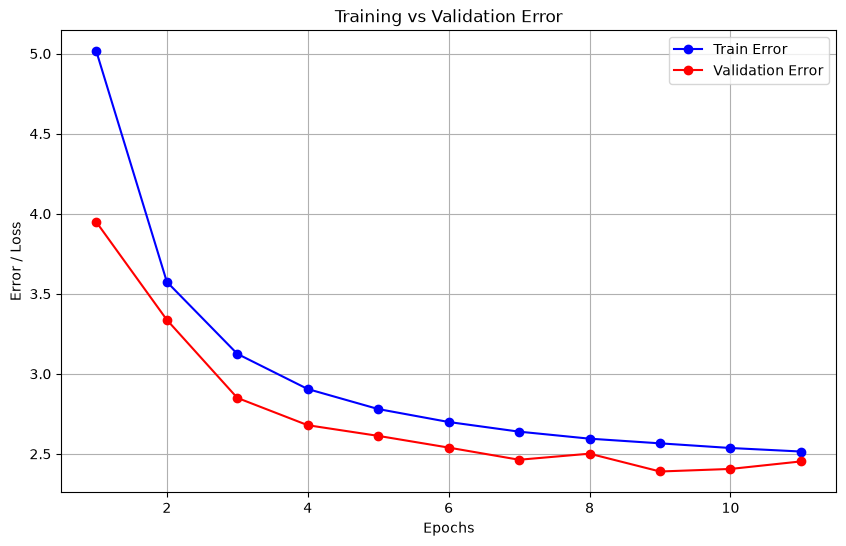

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Error', color='blue', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Error', color='red', marker='o')

plt.title('Training vs Validation Error')
plt.xlabel('Epochs')
plt.ylabel('Error / Loss')
plt.legend()
plt.grid(True)

plt.show()

If the model is already trained before, you can simply load the trained weights below.

In [ ]:
model.load_state_dict(torch.load("custom_resnet34.pth"))

## References

[1] He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep Residual Learning for Image Recognition. 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 770-778. https://arxiv.org/abs/1512.03385

[2] Olga Russakovsky*, Jia Deng*, Hao Su, Jonathan Krause, Sanjeev Satheesh, Sean Ma, Zhiheng Huang, Andrej Karpathy, Aditya Khosla, Michael Bernstein, Alexander C. Berg and Li Fei-Fei. (* = equal contribution) ImageNet Large Scale Visual Recognition Challenge. IJCV, 2015. https://arxiv.org/abs/1409.0575

[3] K. Simonyan and A. Zisserman. Very deep convolutional networks for large-scale image recognition. In ICLR, 2015. https://arxiv.org/abs/1409.1556

[4] A. Krizhevsky, I. Sutskever, and G. Hinton. Imagenet classification with deep convolutional neural networks. In NIPS, 2012. https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html

[5] S. Ioffe and C. Szegedy. Batch normalization: Accelerating deep network training by reducing internal covariate shift. In ICML, 2015. https://arxiv.org/abs/1502.03167

[6] K. He, X. Zhang, S. Ren, and J. Sun. Delving deep into rectifiers: Surpassing human-level performance on imagenet classification. In ICCV, 2015. https://arxiv.org/abs/1502.01852